<a href="https://colab.research.google.com/github/paolatorresr90-create/Aplicacion-web-usando-flask/blob/main/Proyecto_Clasificaci%C3%B3n_de_Im%C3%A1genes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/paolatorresr90-create/Proyecto-Clasificador-de-imagenes.git

fatal: destination path 'Proyecto-Clasificador-de-imagenes' already exists and is not an empty directory.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -r /content/Proyecto-Clasificador-de-imagenes/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bq

In [7]:
import zipfile
import os

# 1. Nueva ruta simplificada
zip_path = '/content/drive/MyDrive/Colab Notebooks/Copia de dogs-vs-cats.zip'

# 2. Destino
extract_path = '/content/dataset_imagenes'

# 3. Descomprimir
try:
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    print("Descomprimiendo... esto puede tardar un minuto.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("¡LOGRADO! Archivos listos en:", extract_path)

    # Esto es para que veas qué carpetas se crearon
    print("Contenido extraído:", os.listdir(extract_path))

except Exception as e:
    print(f"Aún tenemos un problemita: {e}")

Descomprimiendo... esto puede tardar un minuto.
¡LOGRADO! Archivos listos en: /content/dataset_imagenes
Contenido extraído: ['dogs-vs-cats', '__MACOSX']


In [8]:
# Miremos qué hay dentro de la carpeta principal
base_path = '/content/dataset_imagenes/dogs-vs-cats'
print(os.listdir(base_path))

['.DS_Store', 'train', 'sampleSubmission.csv']


In [9]:
import os
import shutil

# 1. Definimos la ruta donde están las fotos mezcladas
train_dir = '/content/dataset_imagenes/dogs-vs-cats/train'

# 2. Definimos las rutas de las nuevas carpetas
cat_dir = os.path.join(train_dir, 'cat')
dog_dir = os.path.join(train_dir, 'dog')

# 3. Creamos las carpetas si no existen
os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

# 4. Movemos los archivos según su nombre
files = os.listdir(train_dir)
count_cats = 0
count_dogs = 0

for filename in files:
    src_path = os.path.join(train_dir, filename)

    # Solo actuamos si es un archivo (ignoramos carpetas)
    if os.path.isfile(src_path):
        if filename.startswith('cat'):
            shutil.move(src_path, os.path.join(cat_dir, filename))
            count_cats += 1
        elif filename.startswith('dog'):
            shutil.move(src_path, os.path.join(dog_dir, filename))
            count_dogs += 1

print(f"¡Proceso terminado!")
print(f"Gatos movidos: {count_cats}")
print(f"Perros movidos: {count_dogs}")

¡Proceso terminado!
Gatos movidos: 12500
Perros movidos: 12500


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuramos el generador (solo reescalado por ahora para ir rápido)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2) # 20% para probar

# 2. Cargamos las imágenes desde las carpetas que acabas de crear
train_generator = train_datagen.flow_from_directory(
    '/content/dataset_imagenes/dogs-vs-cats/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '/content/dataset_imagenes/dogs-vs-cats/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Definimos la ruta en tu Drive
ruta_en_drive = '/content/drive/MyDrive/Colab Notebooks/modelo_perros_gatos.keras'

# Configuramos el guardián
checkpoint = ModelCheckpoint(
    filepath=ruta_en_drive,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# LANZAMOS EL ENTRENAMIENTO
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[checkpoint]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6108 - loss: 0.7049
Epoch 1: val_accuracy improved from None to 0.73200, saving model to /content/drive/MyDrive/Colab Notebooks/modelo_perros_gatos.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/modelo_perros_gatos.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6650 - loss: 0.6173 - val_accuracy: 0.7320 - val_loss: 0.5425
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7599 - loss: 0.4995
Epoch 2: val_accuracy improved from 0.73200 to 0.76780, saving model to /content/drive/MyDrive/Colab Notebooks/modelo_perros_gatos.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/modelo_perros_gatos.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7747 - loss: 0.4751 - val_accuracy: 0.7678 - val_loss: 0.4857
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8169 - loss: 0.4049
Epoch 3: val_accuracy improved

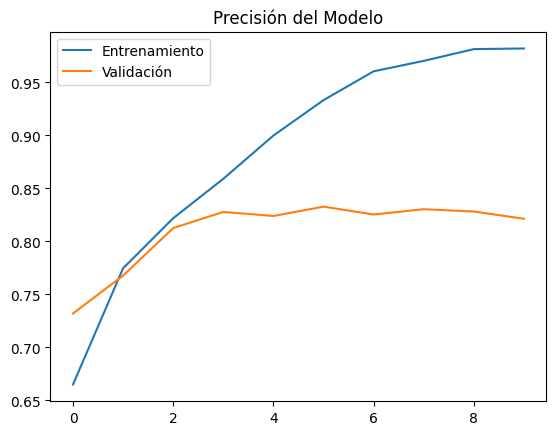

In [13]:
import matplotlib.pyplot as plt

# Graficar la precisión
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.legend()
plt.show()

Cargando modelo desde Drive... esto puede tardar un poco.
¡Modelo cargado!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


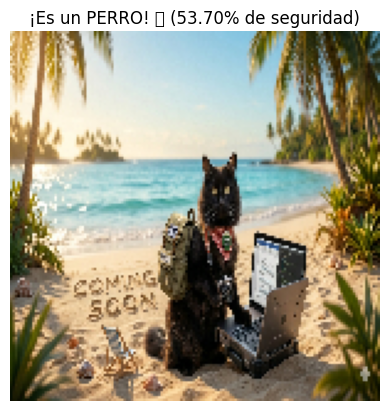

Valor de la neurona de salida: 0.5370


In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Rutas (Asegúrate de que subiste la foto con ese nombre)
modelo_path = '/content/drive/MyDrive/Colab Notebooks/modelo_perros_gatos.keras'
imagen_prueba_path = '/content/drive/MyDrive/Colab Notebooks/prueba.PNG' # <--- Sube tu foto aquí

# 2. Cargar el modelo que guardamos antes
print("Cargando modelo desde Drive... esto puede tardar un poco.")
model = tf.keras.models.load_model(modelo_path)
print("¡Modelo cargado!")

# 3. Función para procesar la imagen (igual que en el entrenamiento)
def preprocesar_imagen(path):
    # Cargar y redimensionar a 150x150 (vital)
    img = image.load_img(path, target_size=(150, 150))
    # Convertir a array numérico
    img_array = image.img_to_array(img)
    # Crear una "bolsa" (batch) para la imagen (batch size de 1)
    img_array = np.expand_dims(img_array, axis=0)
    # Normalizar (dividir por 255 como hicimos antes)
    img_array /= 255.
    return img, img_array

# 4. Cargar y procesar tu imagen
img_original, img_procesada = preprocesar_imagen(imagen_prueba_path)

# 5. ¡HACER LA PREDICCIÓN!
prediction = model.predict(img_procesada)

# 6. Interpretar el resultado (Sigmoid: Perro = 1, Gato = 0)
# Usamos un umbral de 0.5
if prediction[0] > 0.5:
    resultado = "¡Es un PERRO! 🐶"
    probabilidad = prediction[0][0] * 100
else:
    resultado = "¡Es un GATO! 🐱"
    probabilidad = (1 - prediction[0][0]) * 100

# 7. Mostrar la imagen y el veredicto
plt.imshow(img_original)
plt.title(f"{resultado} ({probabilidad:.2f}% de seguridad)")
plt.axis('off')
plt.show()

print(f"Valor de la neurona de salida: {prediction[0][0]:.4f}")

Cargando modelo desde Drive... esto puede tardar un poco.
¡Modelo cargado!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step


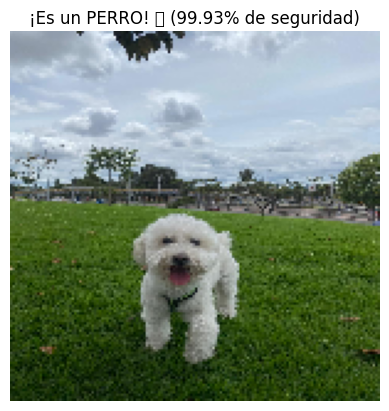

Valor de la neurona de salida: 0.9993


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Rutas (Asegúrate de que subiste la foto con ese nombre)
modelo_path = '/content/drive/MyDrive/Colab Notebooks/modelo_perros_gatos.keras'
imagen_prueba_path = '/content/drive/MyDrive/Colab Notebooks/prueba2.jpg' # <--- Sube tu foto aquí

# 2. Cargar el modelo que guardamos antes
print("Cargando modelo desde Drive... esto puede tardar un poco.")
model = tf.keras.models.load_model(modelo_path)
print("¡Modelo cargado!")

# 3. Función para procesar la imagen (igual que en el entrenamiento)
def preprocesar_imagen(path):
    # Cargar y redimensionar a 150x150 (vital)
    img = image.load_img(path, target_size=(150, 150))
    # Convertir a array numérico
    img_array = image.img_to_array(img)
    # Crear una "bolsa" (batch) para la imagen (batch size de 1)
    img_array = np.expand_dims(img_array, axis=0)
    # Normalizar (dividir por 255 como hicimos antes)
    img_array /= 255.
    return img, img_array

# 4. Cargar y procesar tu imagen
img_original, img_procesada = preprocesar_imagen(imagen_prueba_path)

# 5. ¡HACER LA PREDICCIÓN!
prediction = model.predict(img_procesada)

# 6. Interpretar el resultado (Sigmoid: Perro = 1, Gato = 0)
# Usamos un umbral de 0.5
if prediction[0] > 0.5:
    resultado = "¡Es un PERRO! 🐶"
    probabilidad = prediction[0][0] * 100
else:
    resultado = "¡Es un GATO! 🐱"
    probabilidad = (1 - prediction[0][0]) * 100

# 7. Mostrar la imagen y el veredicto
plt.imshow(img_original)
plt.title(f"{resultado} ({probabilidad:.2f}% de seguridad)")
plt.axis('off')
plt.show()

print(f"Valor de la neurona de salida: {prediction[0][0]:.4f}")